# Домашняя работа 3. Выполнил Ерёмин Иван

In [8]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon

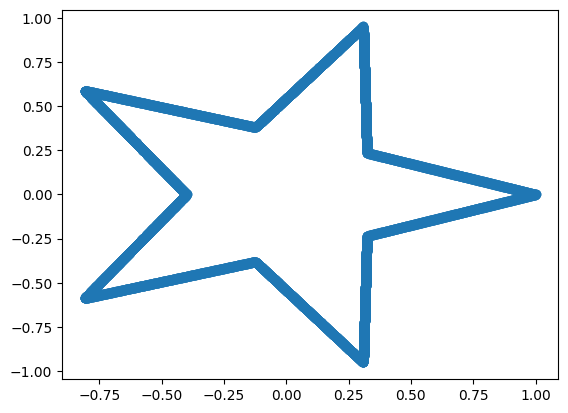

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [53]:
class Config:
    def __init__(self):
        self.data_samples = 5000
        self.batch_size = 256
        self.lr = 1e-3
        self.epochs = 500
        self.hidden_dim = 128
        self.num_timesteps = 100
        self.beta_min = 0.1
        self.beta_max = 20.0

In [54]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)
        return self.net(x_input)

In [55]:
def weight_constant(t, config, beta_func):
    return torch.ones_like(t)

def weight_linear(t, config, beta_func):
    return t + 0.1

def weight_exp(t, config, beta_func):
    return torch.exp(2 * t)

def beta_linear(t, config):
    return config.beta_min + t * (config.beta_max - config.beta_min)

def alpha_cosine(t):
    s = 0.008
    return torch.cos((t + s) / (1 + s) * math.pi / 2) ** 2

def marginal_prob_std(t, config, beta_func):
    if beta_func == beta_linear:
        log_mean_coeff = -0.25 * (config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t**2)
        return torch.exp(log_mean_coeff)

    else:
        s = 0.008
        alpha = torch.cos((t + s) / (1 + s) * math.pi / 2) ** 2
        alpha_0 = math.cos(s / (1 + s) * math.pi / 2) ** 2
        alpha_t = torch.sqrt(alpha / alpha_0)
        return torch.clamp(alpha_t, max=0.999)


def beta_cosine_from_alpha(t):
    s = 0.008
    theta = (t + s) / (1 + s) * math.pi / 2

    alpha = torch.cos(theta) ** 2
    dtheta_dt = math.pi / (2 * (1 + s))

    dalpha_dt = -2 * torch.cos(theta) * torch.sin(theta) * dtheta_dt

    beta = -dalpha_dt / (alpha + 1e-8)
    return torch.clamp(beta, min=1e-5, max=50.0)


In [56]:
class VPTrainer:
    def __init__(self, config, beta_func, weight_func, name, data):
        self.config = config
        self.beta_func = beta_func
        self.weight_func = weight_func
        self.name = name
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        self.data = torch.tensor(data, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)
        self.loss_history = []

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch,) in self.dataloader:
            batch = batch.to(self.device)
            t = torch.rand(batch.shape[0], 1, device=self.device)

            std = marginal_prob_std(t, self.config, self.beta_func)

            z = torch.randn_like(batch)
            x_t = std * batch + torch.sqrt(1.0 - std**2 + 1e-8) * z

            pred_z = self.model(x_t, t)

            weight = self.weight_func(t, self.config, self.beta_func)
            loss = (weight * (pred_z - z)**2).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        print(f"\nTraining {self.name}...")
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            self.loss_history.append(loss)
            if n % 100 == 0:
                print(f'  Epoch {n}, Loss: {loss:.4f}')

In [57]:
def sample_vp_sde(model, config, beta_func, num_samples=5000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)
        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 0.05)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            if beta_func == beta_linear:
                beta_val = beta_linear(t_tensor, config)
            else:
                beta_val = beta_cosine_from_alpha(t_tensor)

            pred_z = model(x, t_tensor)
            std = marginal_prob_std(t_tensor, config, beta_func)
            sigma = torch.sqrt(torch.clamp(1.0 - std**2, min=1e-5))
            score = -pred_z / sigma

            drift = (-0.5 * beta_val * x - beta_val * score) * dt
            diffusion = torch.sqrt(beta_val) * torch.randn_like(x) * math.sqrt(dt)

            x = x - drift + diffusion

        return x.cpu().numpy()

In [58]:
def calculate_metrics(samples, real_samples, bins=50):
    hist_samples, _, _ = np.histogram2d(samples[:, 0], samples[:, 1],
                                        bins=bins, range=[[-1.2, 1.2], [-1.2, 1.2]])
    hist_real, _, _ = np.histogram2d(real_samples[:, 0], real_samples[:, 1],
                                      bins=bins, range=[[-1.2, 1.2], [-1.2, 1.2]])

    hist_samples = hist_samples / (hist_samples.sum() + 1e-8)
    hist_real = hist_real / (hist_real.sum() + 1e-8)

    js_div = jensenshannon(hist_samples.flatten(), hist_real.flatten())**2

    eps = 1e-10
    entropy_samples = entropy((hist_samples + eps).flatten())
    entropy_real = entropy((hist_real + eps).flatten())

    coverage = (hist_samples > 0).sum() / (hist_real > 0).sum()

    return {
        'JS_divergence': js_div,
        'entropy_samples': entropy_samples,
        'entropy_real': entropy_real,
        'coverage': coverage
    }


Training Cosine_Constant...
  Epoch 0, Loss: 0.8542
  Epoch 100, Loss: 0.3144
  Epoch 200, Loss: 0.3012
  Epoch 300, Loss: 0.2943
  Epoch 400, Loss: 0.3027


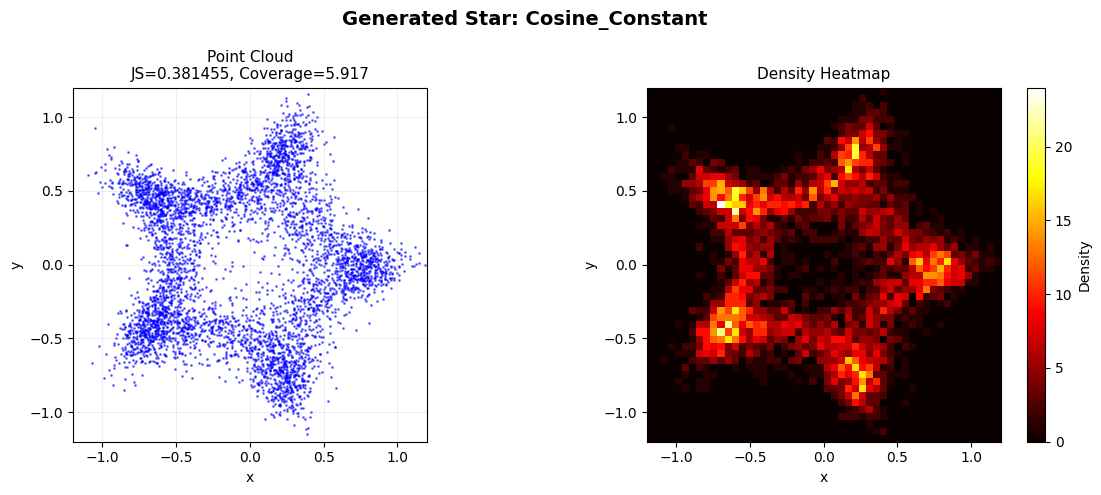


Training Cosine_Linear_Weight...
  Epoch 0, Loss: 0.4697
  Epoch 100, Loss: 0.1100
  Epoch 200, Loss: 0.0993
  Epoch 300, Loss: 0.0975
  Epoch 400, Loss: 0.0986


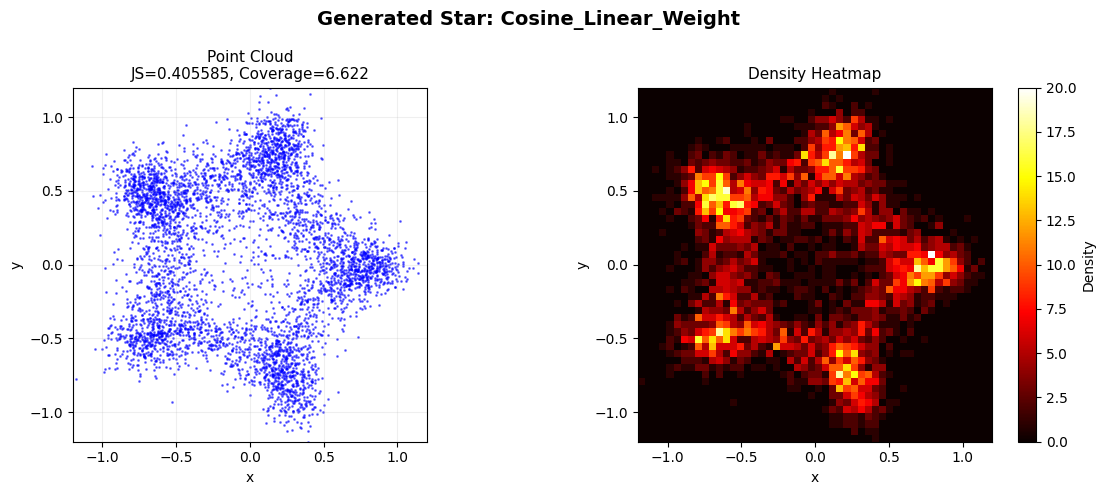


Training Cosine_Exp_Weight...
  Epoch 0, Loss: 2.5173
  Epoch 100, Loss: 0.5417
  Epoch 200, Loss: 0.5363
  Epoch 300, Loss: 0.5133
  Epoch 400, Loss: 0.4946


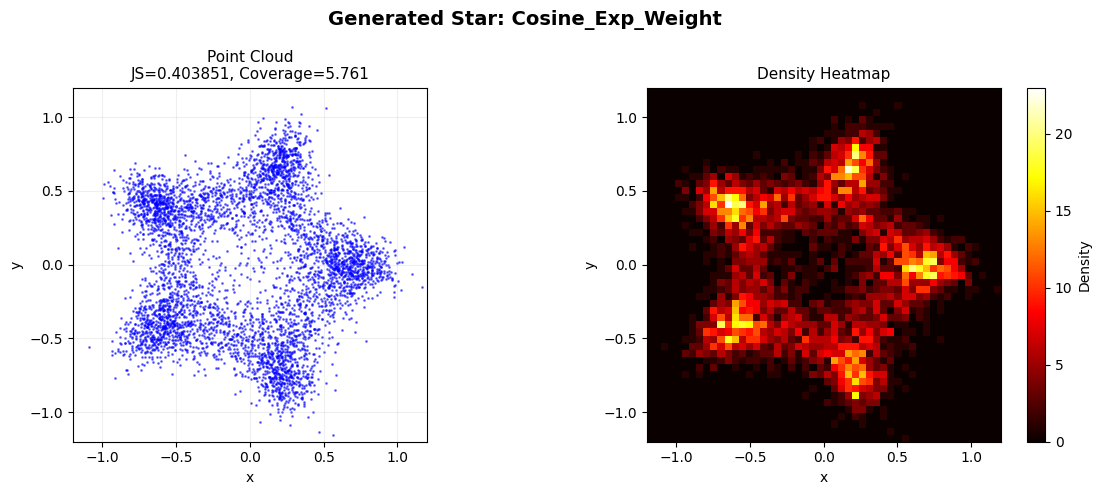


Training Linear_Constant...
  Epoch 0, Loss: 0.8383
  Epoch 100, Loss: 0.2333
  Epoch 200, Loss: 0.2299
  Epoch 300, Loss: 0.2267
  Epoch 400, Loss: 0.2148


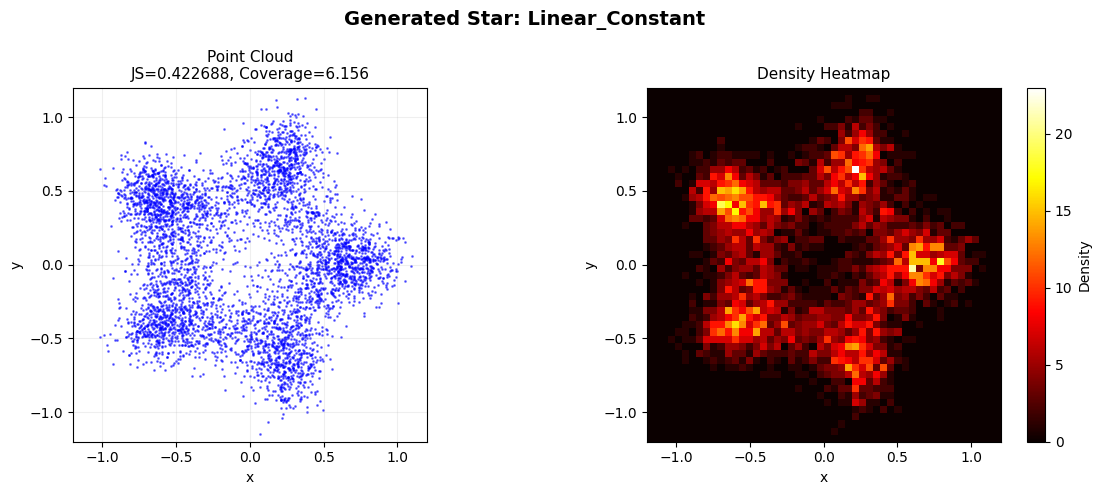


Training Linear_Linear_Weight...
  Epoch 0, Loss: 0.4913
  Epoch 100, Loss: 0.0689
  Epoch 200, Loss: 0.0647
  Epoch 300, Loss: 0.0659
  Epoch 400, Loss: 0.0655


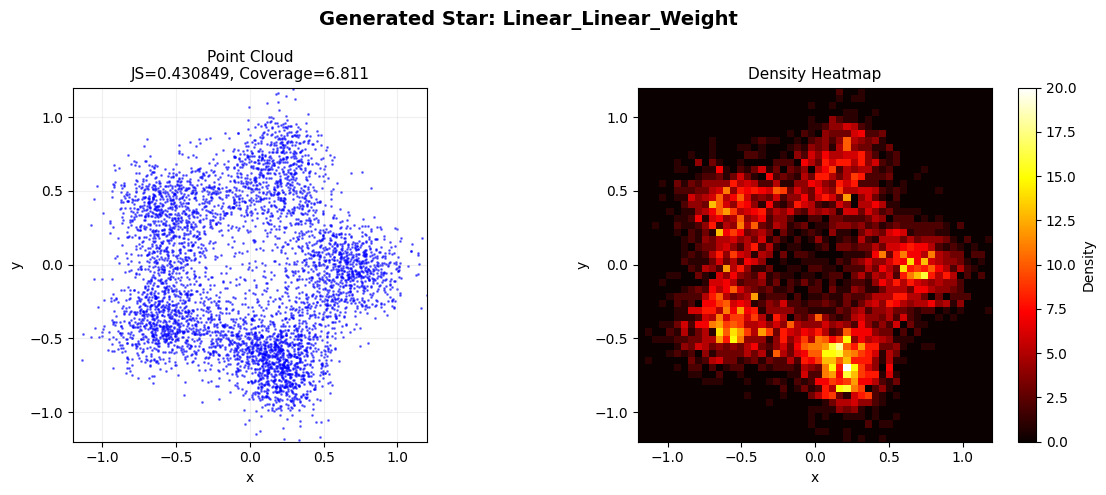


Training Linear_Exp_Weight...
  Epoch 0, Loss: 2.6287
  Epoch 100, Loss: 0.3726
  Epoch 200, Loss: 0.3737
  Epoch 300, Loss: 0.3657
  Epoch 400, Loss: 0.3457


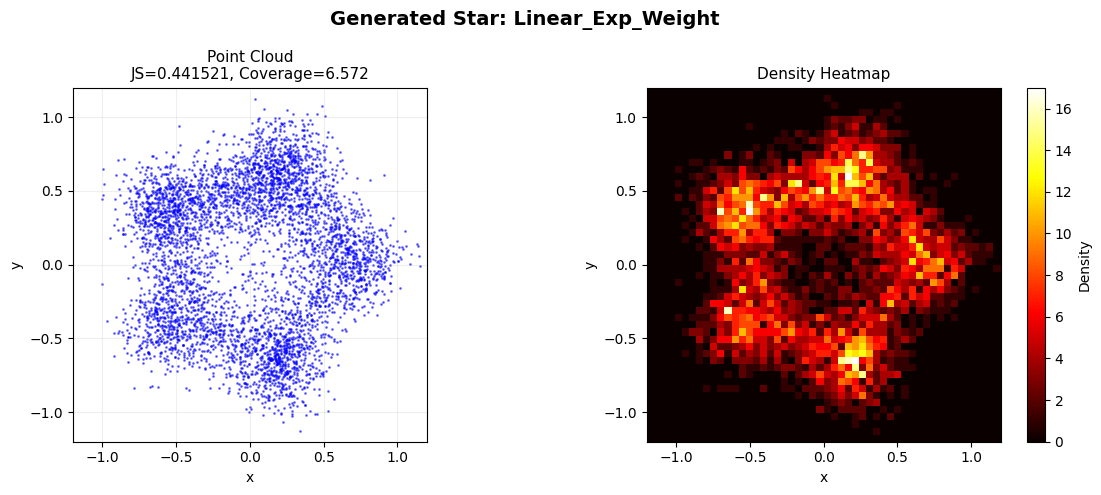

In [59]:
config = Config()
real_star = generate_star(n_samples=5000)

beta_functions = {
    'Cosine': alpha_cosine,
    'Linear': beta_linear,
}

weight_functions = {
    'Constant': weight_constant,
    'Linear_Weight': weight_linear,
    'Exp_Weight': weight_exp
}

all_results = {}

for beta_name, beta_func in beta_functions.items():
    for weight_name, weight_func in weight_functions.items():
        combo_name = f"{beta_name}_{weight_name}"

        trainer = VPTrainer(config, beta_func, weight_func, combo_name, real_star)
        trainer.run()

        samples = sample_vp_sde(trainer.model, config, beta_func, num_samples=5000)
        metrics = calculate_metrics(samples, real_star)

        all_results[combo_name] = {
            'samples': samples,
            'metrics': metrics,
            'loss_history': trainer.loss_history
        }
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f'Generated Star: {combo_name}', fontsize=14, fontweight='bold')

        axes[0].scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.5, c='blue')
        axes[0].set_title(f'Point Cloud\nJS={metrics["JS_divergence"]:.6f}, Coverage={metrics["coverage"]:.3f}', fontsize=11)
        axes[0].set_xlim(-1.2, 1.2)
        axes[0].set_ylim(-1.2, 1.2)
        axes[0].set_aspect('equal')
        axes[0].set_xlabel('x')
        axes[0].set_ylabel('y')
        axes[0].grid(True, alpha=0.2)

        h = axes[1].hist2d(samples[:, 0], samples[:, 1], bins=50, cmap='hot',
                           range=[[-1.2, 1.2], [-1.2, 1.2]])
        plt.colorbar(h[3], ax=axes[1], label='Density')
        axes[1].set_title('Density Heatmap', fontsize=11)
        axes[1].set_xlim(-1.2, 1.2)
        axes[1].set_ylim(-1.2, 1.2)
        axes[1].set_aspect('equal')
        axes[1].set_xlabel('x')
        axes[1].set_ylabel('y')

        plt.tight_layout()
        plt.show()

In [60]:
print("\n" + "="*80)
print("SUMMARY TABLE - METRICS FOR ALL COMBINATIONS")
print("="*80)
print(f"{'Combination':<30} {'JS Divergence':<15} {'Coverage':<10} {'Entropy Ratio':<12}")
print("-"*80)

for name, data in all_results.items():
    metrics = data['metrics']
    entropy_ratio = metrics['entropy_samples'] / metrics['entropy_real']
    print(f"{name:<30} {metrics['JS_divergence']:<15.6f} {metrics['coverage']:<10.3f} {entropy_ratio:<12.3f}")


SUMMARY TABLE - METRICS FOR ALL COMBINATIONS
Combination                    JS Divergence   Coverage   Entropy Ratio
--------------------------------------------------------------------------------
Cosine_Constant                0.381455        5.917      1.316       
Cosine_Linear_Weight           0.405585        6.622      1.336       
Cosine_Exp_Weight              0.403851        5.761      1.311       
Linear_Constant                0.422688        6.156      1.330       
Linear_Linear_Weight           0.430849        6.811      1.350       
Linear_Exp_Weight              0.441521        6.572      1.346       


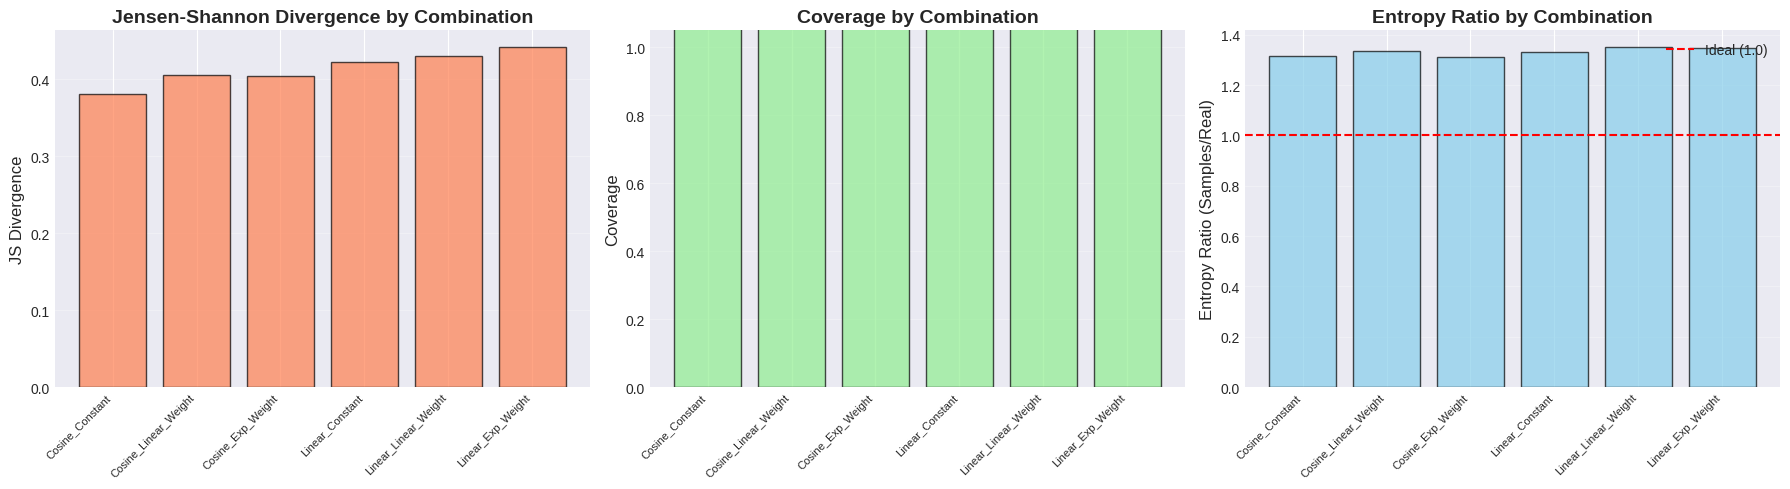

In [64]:
import matplotlib.pyplot as plt
import numpy as np

combinations = list(all_results.keys())
js_div = [all_results[name]['metrics']['JS_divergence'] for name in combinations]
coverage = [all_results[name]['metrics']['coverage'] for name in combinations]
entropy_ratio = [all_results[name]['metrics']['entropy_samples'] / all_results[name]['metrics']['entropy_real']
                  for name in combinations]

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax1 = axes[0]
ax1.bar(range(len(combinations)), js_div, color='coral', alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(combinations)))
ax1.set_xticklabels(combinations, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('JS Divergence', fontsize=12)
ax1.set_title('Jensen-Shannon Divergence by Combination', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.bar(range(len(combinations)), coverage, color='lightgreen', alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(combinations)))
ax2.set_xticklabels(combinations, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Coverage', fontsize=12)
ax2.set_title('Coverage by Combination', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1.05])
ax2.grid(axis='y', alpha=0.3)

ax3 = axes[2]
ax3.bar(range(len(combinations)), entropy_ratio, color='skyblue', alpha=0.7, edgecolor='black')
ax3.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Ideal (1.0)')
ax3.set_xticks(range(len(combinations)))
ax3.set_xticklabels(combinations, rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Entropy Ratio (Samples/Real)', fontsize=12)
ax3.set_title('Entropy Ratio by Combination', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

Лучшая комбинация - Cosine_Constant, поскольку она демонстрирует наименьшее значение JS-дивергенции (0.381), что указывает на максимальное сходство между распределениями сгенерированных и реальных данных. Несмотря на то что её покрытие (5.917) не является самым высоким среди всех вариантов, более низкая дивергенция является более важным показателем качества генерации, чем просто разнообразие образцов. Комбинация также показывает умеренное значение энтропийного отношения (1.316), что, хотя и превышает идеальное значение 1.0, сопоставимо с другими методами.